In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import scipy.stats as stats
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures

print("Imports completed")

Imports completed


In [20]:
#Creamos el datos dataframe a partir del archivo CSV

PATH_DIRECTORIO_DATOS = "..\\..\\data\\raw\\dataset_practica_final.csv"
print("Directorio de datos:", PATH_DIRECTORIO_DATOS)

ds_reservas_raw = pd.read_csv(PATH_DIRECTORIO_DATOS)
ds_reservas_raw.head()

Directorio de datos: ..\..\data\raw\dataset_practica_final.csv


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [22]:
# Mostrar las dimensiones del DataFrame
ds_reservas_raw.shape
# Mostrar información del DataFrame
ds_reservas_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [23]:
# Descripción estadística de las columnas numéricas. Recomendación el usar .transpose() para ver el listado de variables
ds_reservas_raw.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [25]:
# Recomendado tener todos los nombres de las variables en minúsculas
ds_reservas_raw.columns = ds_reservas_raw.columns.str.lower()
ds_reservas_raw.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [26]:
# Verificar si hay valores nulos en el DataFrame
ds_reservas_raw.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [27]:
# Verificar si hay valores duplicados en el DataFrame
ds_reservas_raw.duplicated().sum()

31994

<Axes: xlabel='is_canceled', ylabel='Count'>

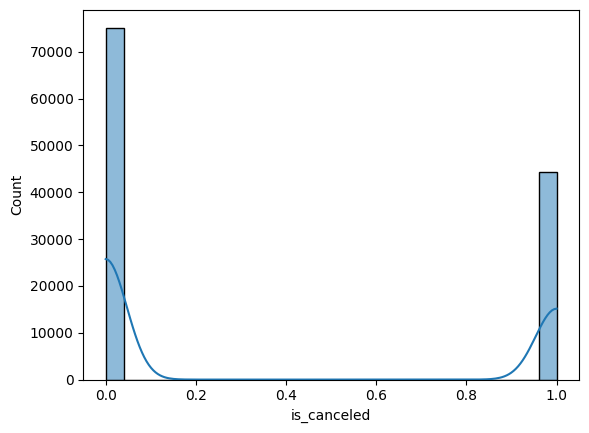

In [29]:
# Visualización de la distribución de la variable "is_cancelled" usando seaborn
sns.histplot(ds_reservas_raw, x='is_canceled', kde=True)

<Axes: xlabel='calories', ylabel='Count'>

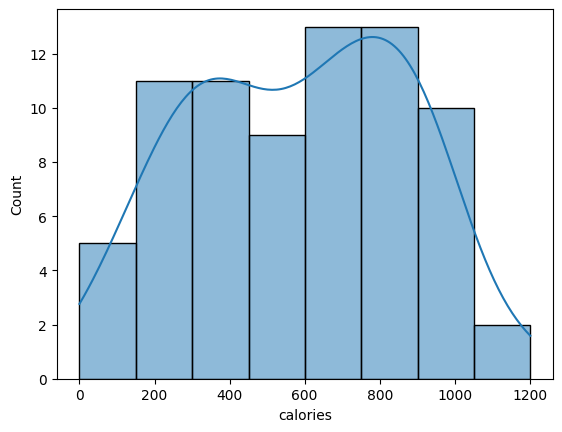

In [ ]:
# Visualización de la distribución de la variable "calories" usando seaborn
sns.histplot(ds_reservas_raw, x='calories', kde=True)

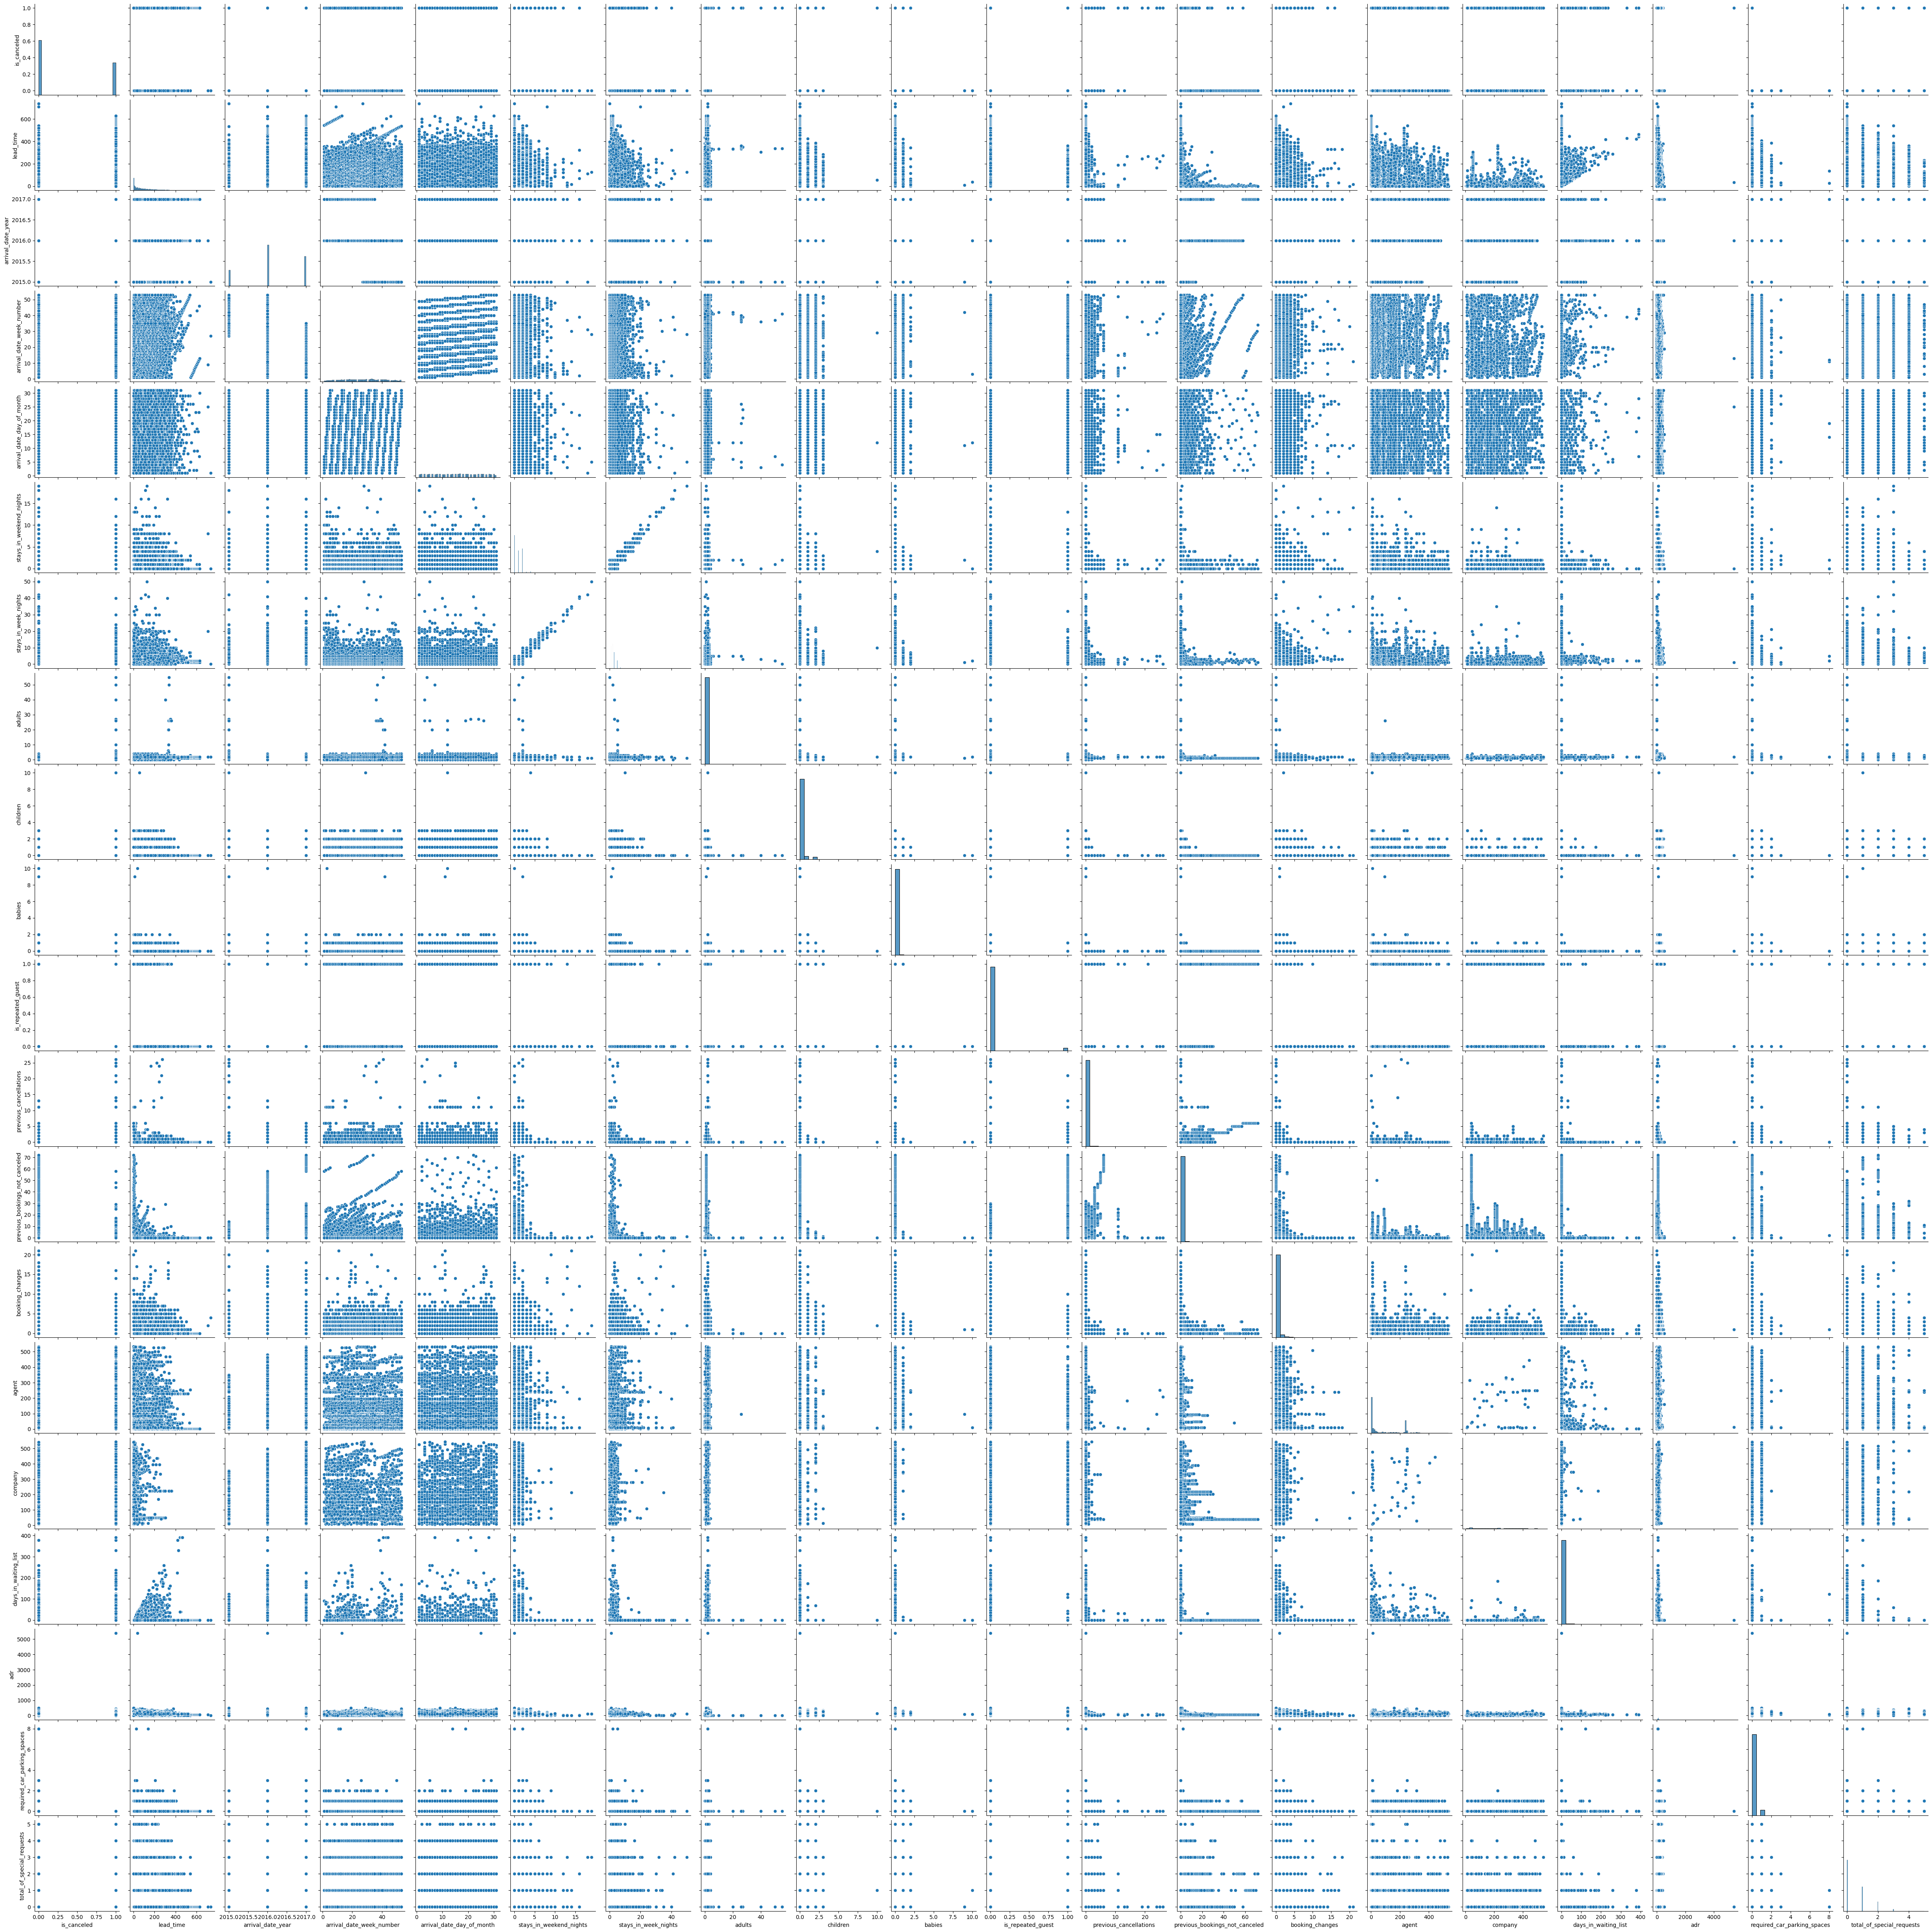

In [30]:
# Visualización de la relación  usando seaborn
sns.pairplot(ds_reservas_raw)

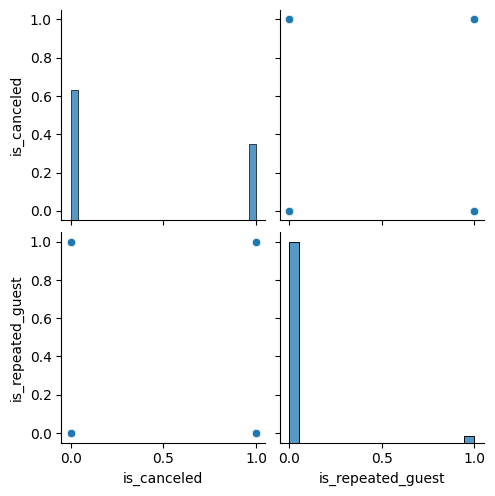

In [31]:
# Visualización de la relación entre "calories" y "time" usando seaborn
sns.pairplot(ds_reservas_raw, vars=['is_canceled', 'is_repeated_guest'])

In [11]:
# Calculamos las métricas de evaluación
def calcular_metricas_evaluacion(y_prediccion: np.ndarray, y_real: np.ndarray, verbose: bool = True):
    """Calcula las métricas de evaluación para un modelo de regresión.
    
    Calcula cuatro métricas comunes para evaluar modelos de regresión: MSE (Error Cuadrático Medio),
    RMSE (Raíz del Error Cuadrático Medio), MAE (Error Absoluto Medio) y R² (Coeficiente de determinación).
    Opcionalmente imprime los resultados en un formato legible.
    
    Args:
        y_prediccion (np.ndarray): Valores predichos por el modelo.
        y_real (np.ndarray): Valores reales observados.
        verbose (bool, optional): Si es True, imprime las métricas calculadas. Por defecto es True.
    
    Returns:
        tuple[float, float, float, float]: Una tupla con cuatro valores en el siguiente orden:
            - mse: Error cuadrático medio.
            - rmse: Raíz del error cuadrático medio.
            - mae: Error absoluto medio.
            - r2: Coeficiente de determinación.
    
    Example:
        >>> mse, rmse, mae, r2 = calcular_metricas_evaluacion(modelo.predict(X_test), y_test)
        >>> print(f"R²: {r2:.4f}")
    """
    
    mse = mean_squared_error(y_real, y_prediccion)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_real, y_prediccion)
    r2 = r2_score(y_real, y_prediccion)

    if verbose:
        print("\nEvaluación del modelo:")
        print(f"MSE (Error cuadrático medio): {mse:.4f}")
        print(f"RMSE (Raíz del error cuadrático medio): {rmse:.4f}")
        print(f"MAE (Error absoluto medio): {mae:.4f}")
        print(f"R² (Coeficiente de determinación): {r2:.4f}")
        print(f"El modelo explica aproximadamente el {r2:.2%} de la varianza")
    
    return mse, rmse, mae, r2

def plot_regresion_lineal_interactiva(df: pd.DataFrame, variable_independiente: str, variable_dependiente: str, modelo: LinearRegression, titulo: str = "Regresión Lineal", xaxis_titulo: str = "X", yaxis_titulo: str = "Y") -> go.Figure:
    """Genera un gráfico interactivo de regresión lineal usando Plotly.
    
    Crea una visualización interactiva que muestra los datos originales como puntos y la línea
    de regresión lineal ajustada. También muestra la ecuación del modelo y las métricas de evaluación
    (MSE, RMSE, MAE, R²) en anotaciones sobre el gráfico.
    
    Args:
        df (pd.DataFrame): DataFrame que contiene los datos para visualizar.
        variable_independiente (str): Nombre de la columna con la variable independiente (X).
        variable_dependiente (str): Nombre de la columna con la variable dependiente (Y).
        modelo (LinearRegression): Modelo de regresión lineal previamente entrenado.
        titulo (str, optional): Título del gráfico. Por defecto es "Regresión Lineal".
        xaxis_titulo (str, optional): Título del eje X. Por defecto es "X".
        yaxis_titulo (str, optional): Título del eje Y. Por defecto es "Y".
    
    Returns:
        go.Figure: Objeto Figure de Plotly que puede ser mostrado con .show() o 
                   incluido en un dashboard.
    
    Example:
        >>> modelo = LinearRegression()
        >>> modelo.fit(df[["tiempo"]], df["ventas"])
        >>> fig = plot_regresion_lineal_interactiva(
        ...     df, 
        ...     variable_independiente="tiempo",
        ...     variable_dependiente="ventas",
        ...     modelo=modelo,
        ...     titulo="Ventas vs Tiempo",
        ...     xaxis_titulo="Tiempo (días)",
        ...     yaxis_titulo="Ventas ($)"
        ... )
        >>> fig.show()
    """
    
    # Calcular las métricas de evaluación
    X = df[[variable_independiente]]
    y = df[variable_dependiente]
    
    y_pred = modelo.predict(X)
    mse, rmse, mae, r2 = calcular_metricas_evaluacion(y_pred, y, verbose=False)

    # Crear la figura
    fig = go.Figure()

    # Añadir los puntos de datos
    fig.add_trace(
        go.Scatter(
            x=df[variable_independiente], 
            y=df[variable_dependiente],
            mode='markers',
            name='Datos reales',
            marker=dict(color='blue', size=8, opacity=0.6)
        )
    )

    # Añadir la línea de regresión
    fig.add_trace(
        go.Scatter(
            x=df[variable_independiente], 
            y=y_pred,
            mode='lines',
            name='Regresión lineal',
            line=dict(color='red', width=2)
        )
    )

    # Coeficientes del modelo
    coeficiente = modelo.coef_[0]
    intercepto = modelo.intercept_

    # Ecuación y métricas para mostrar en el gráfico
    equation_text = f"Ecuación: y = {coeficiente:.4f} × x + {intercepto:.4f}"
    metrics_text = f"MSE: {mse:.2f}, RMSE: {rmse:.2f}<br>MAE: {mae:.2f}, R²: {r2:.4f}"

    # Añadir anotaciones
    fig.add_annotation(
        x=0.02,
        y=0.98,
        xref="paper",
        yref="paper",
        text=equation_text,
        showarrow=False,
        font=dict(size=14),
        align="left",
        bgcolor="rgba(255, 255, 255, 0.8)",
        bordercolor="black",
        borderwidth=1
    )

    fig.add_annotation(
        x=0.02,
        y=0.90,
        xref="paper",
        yref="paper",
        text=metrics_text,
        showarrow=False,
        font=dict(size=12),
        align="left",
        bgcolor="rgba(255, 255, 255, 0.8)",
        bordercolor="black",
        borderwidth=1
    )

    # Configuración del diseño
    fig.update_layout(
        title=titulo,
        xaxis_title=xaxis_titulo,
        yaxis_title=yaxis_titulo,
        legend=dict(x=0.02, y=0.02),
        plot_bgcolor='white',
        width=900,
        height=600
    )

    # Añadir cuadrícula
    fig.update_xaxes(showgrid=True, gridwidth=0.5, gridcolor='lightgray')
    fig.update_yaxes(showgrid=True, gridwidth=0.5, gridcolor='lightgray')

    return fig